# Libraries and core functions

In [1]:
// For collections
import scala.collection.mutable
import scala.math.{pow, exp, tanh}
import scala.util.Random

// For calculations
import $ivy.`org.apache.commons:commons-math3:3.6.1`
import org.apache.commons.math3.analysis.function.{Atanh}
import org.apache.commons.math3.ode.{FirstOrderDifferentialEquations, FirstOrderIntegrator}
import org.apache.commons.math3.ode.nonstiff.{ClassicalRungeKuttaIntegrator, DormandPrince853Integrator}
import org.apache.commons.math3.linear.{MatrixUtils, ArrayRealVector, Array2DRowRealMatrix, RealMatrix, RealVector}

// For reading files
import scala.io.Source
import java.io.File

// For Rust
import $ivy.`net.java.dev.jna:jna:5.14.0`

import com.sun.jna.{Native, Library}

// For display
import $ivy.`org.jfree:jfreechart:1.5.6`

import almond.display.Image

import org.jfree.chart.plot.PlotOrientation
import org.jfree.chart.plot.XYPlot
import org.jfree.chart.renderer.xy.XYItemRenderer
import org.jfree.chart.ChartFactory
import org.jfree.chart.JFreeChart

import javax.imageio.ImageIO

import java.io.ByteArrayOutputStream
import org.jfree.data.xy.{DefaultXYDataset, XYSeries, XYSeriesCollection }
import org.jfree.chart.renderer.xy.XYLineAndShapeRenderer
import java.awt.image.BufferedImage
import java.awt.geom.{Ellipse2D, Rectangle2D}
import java.awt.{Color, Font, Shape, BasicStroke, Polygon, Stroke }
import javax.imageio.ImageIO

import scala.collection.mutable

import scala.math.{pow, exp, tanh}

import scala.util.Random

// For calculations

import $ivy.$                                       

import org.apache.commons.math3.analysis.function.{Atanh}

import org.apache.commons.math3.ode.{FirstOrderDifferentialEquations, FirstOrderIntegrator}

import org.apache.commons.math3.ode.nonstiff.{ClassicalRungeKuttaIntegrator, DormandPrince853Integrator}

import org.apache.commons.math3.linear.{MatrixUtils, ArrayRealVector, Array2DRowRealMatrix, RealMatrix, RealVector}

// For reading files

import scala.io.Source

import java.io.File

// For Rust

import $ivy.$                            


import com.sun.jna.{Native, Library}

// For display

import $ivy.$                           


import almond.display.Image


import org.jfree.chart.plot.PlotOrientation

import org.jfree.chart.plot.XYPlot

import org.jfree.chart.renderer.xy.XYItemRenderer

import org.jfree.chart.ChartFactory

import org.jfree.chart.JFreeChart



## Display

https://developer.mozilla.org/en-US/docs/Web/CSS/Reference/Properties/image-rendering

In [2]:

def display_image(im: BufferedImage) = {
  val baos = new ByteArrayOutputStream()
  ImageIO.write(im, "png", baos)
  almond.display.Image(baos.toByteArray)
}

enum ImageRenderingType {
  case auto, pixelated
}

def display_images_html(
  ims: Array[BufferedImage],
  renderingType: ImageRenderingType = ImageRenderingType.auto,
  padding: Int = 20,
  width: Int = 400,
  height: Int = 400,
  text: String = ""
) = {
  val imagesHtml = ims.zipWithIndex.map { case (img, idx) =>
      val out = new java.io.ByteArrayOutputStream()
      javax.imageio.ImageIO.write(img, "png", out)
      val b64 = java.util.Base64.getEncoder.encodeToString(out.toByteArray)
      s"""<img src="data:image/png;base64,$b64"
          style="width:${width}px; 
                 height:${height}px; 
                 image-rendering:${renderingType.toString()}; 
                 display:block;
                 background:#1e1e1e;
                 border-radius: 6px;
                 padding: ${padding}"/>"""
    }.mkString

  // Стиль шапки (только если текст не пустой)
  val headerHtml = if (text.nonEmpty) 
    s"""<div style="text-align:left; color:rgba(146, 168, 255, 0.5); font-size:18px; font-weight:500; 
                    margin-bottom:6px; line-height:1.4; padding: 0px 0px 2px 8px; border-radius:2px">
          $text
        </div>""" 
  else ""

  // Сетка изображений
  val gridStyle = 
    s"display: grid; " +
    s"grid-template-columns: repeat(auto-fill, minmax(${width}px, 1fr)); " +
    s"gap: ${padding}px; " +
    s"justify-items: center; " +
    s"align-items: center;"

  // Внешний контейнер с тёмным фоном
  val containerStyle = 
    s"background: #0f0f0f; " +          // Глубокий тёмный фон
    s"padding: ${padding}px; " +
    s"font-family: 'Segoe UI', Tahoma, Geneva, Verdana, sans-serif; " +
    s"border-radius: 2px; " +
    s"padding: 4px 12px 4px 12px; " +
    s"box-shadow: 0 4px 10px rgba(0,0,0,0.6);"
    
  almond.display.Html(
    s"""<div style="$containerStyle">
          $headerHtml
          <div style="$gridStyle">$imagesHtml</div>
        </div>"""
  )
}

defined function display_image
defined class ImageRenderingType
defined function display_images_html

In [3]:
def circle(r: Double): Shape = new Ellipse2D.Double(-r, -r, 2 * r, 2 * r)
def square(r: Double): Shape = new Rectangle2D.Double(-r, -r, 2 * r, 2 * r)
def triangle(r: Double): Shape = {
  val ri = r.toInt
  new Polygon(Array(0, ri, -ri), Array(-ri, ri, ri), ri)
}

def solid(width: Float = 2f): Stroke = new BasicStroke(width, BasicStroke.CAP_ROUND, BasicStroke.JOIN_ROUND)
def dashed(width: Float = 2f, dash: Float = 8f, gap: Float = 4f): Stroke = 
  new BasicStroke(width, BasicStroke.CAP_ROUND, BasicStroke.JOIN_ROUND, 0f, Array(dash, gap), 0f)
def dotted(width: Float = 2f): Stroke = 
  new BasicStroke(width, BasicStroke.CAP_ROUND, BasicStroke.JOIN_ROUND, 0f, Array(2f, 4f), 0f)

enum DrawMode:
  case LinesOnly, PointsOnly, LinesAndPoints

case class SeriesStyle(
  color: Color = Color.BLACK,
  shape: Shape = circle(4),
  lineWidth: Float = 2f,
  Stroke: Stroke = solid(2f),
  drawMode: DrawMode = DrawMode.LinesAndPoints,
  shapeFilled: Boolean = true,
  // Optional: per-series renderer hints (e.g., for transparency)
  rendererHints: Map[AnyRef, AnyRef] = Map.empty
)


def display_chart(
  chart: JFreeChart,
  styles: Map[String, SeriesStyle] = Map.empty,
  defaultStyle: SeriesStyle = SeriesStyle(), // fallbacm for unstyled series
  backgroundColor: Color = Color.WHITE,
  gridlineColor: Color = new Color(220, 220, 220, 120),
  width: Int = 1000,
  height: Int = 600
) = {
  val plot = chart.getPlot().asInstanceOf[XYPlot]
  val renderer = plot.getRenderer().asInstanceOf[XYLineAndShapeRenderer]
  val dataset = plot.getDataset().asInstanceOf[XYSeriesCollection]

  // Global styling
  plot.setBackgroundPaint(backgroundColor)
  plot.setDomainGridlinePaint(gridlineColor)
  plot.setRangeGridlinePaint(gridlineColor)

  // Improve fonts
  val axisFont = new Font("Arial", Font.PLAIN, 12)
  val labelFont = new Font("Arial", Font.BOLD, 14)
  plot.getDomainAxis().setLabelFont(labelFont)
  plot.getRangeAxis().setLabelFont(labelFont)
  plot.getDomainAxis().setTickLabelFont(axisFont)
  plot.getRangeAxis().setTickLabelFont(axisFont)
  chart.getTitle().setFont(new Font("Arial", Font.BOLD, 16))

  // Apply per-series styles by NAME
  val seriesCount = dataset.getSeriesCount()
  for (i <- 0 until seriesCount) {
    val series = dataset.getSeries(i)
    val seriesName = series.getKey.toString
    val style = styles.getOrElse(seriesName, defaultStyle)

    // Set visual properties
    renderer.setSeriesPaint(i, style.color)
    renderer.setSeriesShape(i, style.shape)
    renderer.setSeriesStroke(i, style.Stroke)
    renderer.setSeriesShapesFilled(i, style.shapeFilled)

    // Draw mode logic
    style.drawMode match {
      case DrawMode.LinesOnly       => renderer.setSeriesLinesVisible(i, true);  renderer.setSeriesShapesVisible(i, false)
      case DrawMode.PointsOnly      => renderer.setSeriesLinesVisible(i, false); renderer.setSeriesShapesVisible(i, true)
      case DrawMode.LinesAndPoints  => renderer.setSeriesLinesVisible(i, true);  renderer.setSeriesShapesVisible(i, true)
    }
  }

  // Render image
  val img = chart.createBufferedImage(width, height, BufferedImage.TYPE_INT_ARGB, null)
  val baos = new ByteArrayOutputStream()
  ImageIO.write(img, "png", baos)
  almond.display.Image(baos.toByteArray)
}

defined function circle
defined function square
defined function triangle
defined function solid
defined function dashed
defined function dotted
defined class DrawMode
defined class SeriesStyle
defined function display_chart

# Hopfield

https://en.wikipedia.org/wiki/Hopfield_network#Convergence_properties_of_discrete_and_continuous_Hopfield_networks

Лучше в статье:
https://pmc.ncbi.nlm.nih.gov/articles/PMC346238/

https://commons.apache.org/proper/commons-math/javadocs/api-3.6.1/org/apache/commons/math3/linear/ArrayRealVector.html

## Theory

Классическая модель сети Хопфилда состоит из состояния нейронов - $x$ - вектор длины N и весов - матрицы связей от нейрона $i$ к нейрону $j$ - $T$ - размера N на N. Важно, что матрица весов $T$ непрерывна. Учится на паттернах $p^k$ - векторах длины N.

Нейроны могут хранить как двоичную информацию, так и вещественные числа, в зависимости от выбора динамики и правила обучения.

**Для дискретного случая** и бинарного паттерна с компонентами из $\{0,1\}$ имеем уравнение вида:
$$
x_i = \begin{cases} 1 \quad if \ \sum_{j \neq i} T_{ij} \ x_j \geq \theta_i, \\ 0 \quad otherwise. \end{cases}
$$
или так ($T_{ii} = 0$)
$$
x_i = \begin{cases} 1 \quad if \ \langle T_{row=i}, x \rangle \geq \theta_i, \\ 0 \quad otherwise. \end{cases}
$$
где $\theta_i$ - погрешность активации.

Причём, можно заменить $\{0,1\}$ на $\{-1,1\}$ в зависимости от правил обучения.

Динамика может быть асинхронная (произвольная активация или наложен порядок активации) и синхронная (одновременная активация - нереалистично).

**Для непрерывного случая** имеем дифференциальное уравнение вида:

$$
\tau_f \frac{dx_i}{dt} = \sum\limits_{j=1}^{N_f} T_{ij} V_j - x_i + I_i
$$

T - матрица весов связей, $V_i$ = функция активации $g(x_i)=\frac{\partial L_{x}}{\partial x_{i}}$, где $L$ - функция от энергии.

Отсюда по формулам Эйлера можно вывести изменение $x_i$:

$$
\frac{dx_i}{dt} = \langle T_{row=i}, V \rangle - x_i + I_i
$$

$$
x = x + \tau_f \frac{dx}{dt}
$$

Есть также современная динамика с использованием скрытых слоёв, но здесь мы её не рассматриваем.

---

### Обучение весов

**Правило Хэбба** для дискретной динамики.
Для компонент паттернов $p_i$ взятых из $\{0,1\}$:
$$
T_{ij}=\sum_k (2p_i^k-1)(2p_j^k-1)
$$
Для $\{-1,1\}$:
$$
T_{ij}=\frac{1}{n}\sum_{k=1}^n p_i^k p_j^k
$$
Можно заметить, что это внешнее произведение. Важно, что сама матрица весов $T$ непрерывна и на диагонали всегда 0 - $T_{ii} = 0$.

Также было замечено, что не хватает нормализации весов. Можно попробовать добавить её.

**Сторки**


Хэбб и Сторки обучаются за одну итерацию.

**Скоростной градиент** для непрерывной динамики.

Непрерывная динамика сети Хопфилда
$$
\tau_f \frac{dx_i}{dt} = \sum\limits_{j=1}^{N_f} T_{ij} V_j - x_i + I_i
$$
рассматривается в виде динамической системы $\dot{x} = \omega(x,\theta,t)$, где $\theta$ - веса матрицы $T$.

Скоростной градиент имеет вид
$$
\frac{d\theta}{dt} = -\Gamma \nabla_{\theta}{\omega(x,\theta,t)}
$$
$$
\omega(x,\theta,t) = \frac{dQ}{dt}
$$

Функционал $Q$

локальный $Q = Q(x(t), t)$

интегральный $Q = \int\limits_0^t R(x(s),\theta(s),s) ds$

Можно заметить, что в нашем случае система адаптивная, где устойчивость достигается за счёт настройки только внутренних параметров.

## Images

Загрузим изображения

In [4]:
import javax.imageio.ImageIO
import java.io.File
import java.awt.image.BufferedImage

def get_images(images_count: Int, folder: String, file_name: String): Array[BufferedImage] = {
  val images: Array[BufferedImage] = new Array[BufferedImage](images_count)

  for (i <- 0 until images_count) {
    val image = ImageIO.read(new File(s"data/hopfield/$folder/$file_name$i.png"))
    println(s"Image loaded: ${image.getWidth}x${image.getHeight} pixels")
    images(i) = image
  }
  return images
}

import javax.imageio.ImageIO

import java.io.File

import java.awt.image.BufferedImage


defined function get_images

In [5]:
val images = get_images(3, "test", "f")
val images_numbers = get_images(10, "numbers", "")

display_images_html(images, ImageRenderingType.pixelated, 10, 100, 100, "Картинки")
display_images_html(images_numbers, ImageRenderingType.pixelated, 10, 100, 100, "Цифры")

Image loaded: 8x8 pixels
Image loaded: 8x8 pixels
Image loaded: 8x8 pixels
Image loaded: 6x7 pixels
Image loaded: 6x7 pixels
Image loaded: 6x7 pixels
Image loaded: 6x7 pixels
Image loaded: 6x7 pixels
Image loaded: 6x7 pixels
Image loaded: 6x7 pixels
Image loaded: 6x7 pixels
Image loaded: 6x7 pixels
Image loaded: 6x7 pixels


Картинки

Цифры

images: Array[BufferedImage] = Array(
  BufferedImage@c5d9fac: type = 6 ColorModel: #pixelBits = 32 numComponents = 4 color space = java.awt.color.ICC_ColorSpace@6051dbf7 transparency = 3 has alpha = true isAlphaPre = false ByteInterleavedRaster: width = 8 height = 8 #numDataElements 4 dataOff[0] = 3,
  BufferedImage@73ad37e8: type = 6 ColorModel: #pixelBits = 32 numComponents = 4 color space = java.awt.color.ICC_ColorSpace@6051dbf7 transparency = 3 has alpha = true isAlphaPre = false ByteInterleavedRaster: width = 8 height = 8 #numDataElements 4 dataOff[0] = 3,
  BufferedImage@aa9de09: type = 6 ColorModel: #pixelBits = 32 numComponents = 4 color space = java.awt.color.ICC_ColorSpace@6051dbf7 transparency = 3 has alpha = true isAlphaPre = false ByteInterleavedRaster: width = 8 height = 8 #numDataElements 4 dataOff[0] = 3
)
images_numbers: Array[BufferedImage] = Array(
  BufferedImage@1ae908a: type = 6 ColorModel: #pixelBits = 32 numComponents = 4 color space = java.awt.color.ICC_ColorS

Теперь напишем Кодировщик для картинок. Нужно преобразовывать изображение в разные вектора с данными. Для Хэбба в вектор с бинарными данными, так как стандартное правило Хебба поддерживает только бинарные вектора.

Если будет 24 бита на цвет пикселя, то мы не теряем никакой информации, но тогда получим вектор из 24 * 8 * 8 элементов = 1536. 

Правило обычного кодирования просто записывает биты в вектора.

Можно закодировать иначе: задать правило кодирования пикселя на каждую шестнадцатеричную компоненту RRGGBB:
> если больше 7, тогда 1, иначе 0

Тогда выйдет 6 бит на цвет пикселя, но часть информации будет утеряна. Получим вектор из 6 * 8 * 8 элементов = 384.

Или в непрерывном случае просто записываем цвет Int как он есть в Double

Ошибка добавляется к компонентам цвета по отдельности.

https://commons.apache.org/proper/commons-math/userguide/linear.html

In [6]:
// Colors are represented as Int objects. 
// The three components red, green, and blue 
// are "packed" together into one integer. 
// Each component has 8 bits, and therefore 
// can have a value between 0 and 255. 
// The packed color is a 32-bit integer, 
// whose bits look like this:
// tttt tttt rrrr rrrr gggg gggg bbbb bbbb
// TT RR GG BB in 16

trait IColorEncoder {
  val move: Int
  val rand: Random

  def encode_color(index: Int, color: Int, target: ArrayRealVector, err_b: Double): Unit
  def decode_color(index: Int, target: ArrayRealVector): Int
}

class EncoderColorBits extends IColorEncoder {
  val move: Int = 24
  val rand: Random = new Random

  def encode_color(index: Int, color: Int, target: ArrayRealVector, err_b: Double): Unit = {
    var t = target
    val h = index
    var c = color
    // Give error to every xxxx component of "rrrr rrrr gggg gggg bbbb bbbb"
    val err = () => { ((rand.nextDouble() - 0.5) * 2.0 * err_b).toInt }
    c += err() + (err() << 4) + (err() << 8) + (err() << 12) + (err() << 16) + (err() << 20)

    for (g <- 0 until move) {
      val value = if (((c >> g) & 1) == 1) 1.0 else -1.0
      t.setEntry(h + g, value)
    }
  }

  def decode_color(index: Int, target: ArrayRealVector): Int = {
    var t = target
    val h = index
    var c = 0
    for (g <- 0 until move) {
      val bit = if (t.getEntry(h + g) > 0.0) 1 else 0
      c = c | (bit << g)
    }
    c
  }
}

class EncoderColorMono extends IColorEncoder {
  val move: Int = 1
  val rand: Random = new Random

  def encode_color(index: Int, color: Int, target: ArrayRealVector, err_b: Double): Unit = {
    val t = target
    val h = index
    val c = color
    // Give error to every xxxx component of "rrrr rrrr gggg gggg bbbb bbbb"
    val r = ((rand.nextDouble() - 0.5) * 2.0 * err_b).toInt
    if ((-c.toDouble / 16777216.0).toInt + r > 0) {
      t.setEntry(h, -1.0)  
    }
    else {
      t.setEntry(h, 1.0)      
    }
  }

  def decode_color(index: Int, target: ArrayRealVector): Int = {
    val t = target
    val h = index
    val c = (target.getEntry(h)).toInt
    if (c > 0.0) {
      return 0xFFFFFF
    }
    else {
      return 0
    }
  }
}

def encode_images(images: Array[BufferedImage], width: Int, height: Int, encoder: IColorEncoder, err: Double): Array[ArrayRealVector] = {
  val images_count = images.length
  val pattern_length = encoder.move * height * width
  val patterns = new Array[ArrayRealVector](images_count)

  for (k <- 0 until images_count) {
    val v = ArrayRealVector(pattern_length)
    val im = images(k)
    var h = 0
    for (i <- 0 until width) {
      for (j <- 0 until height) {
        val c = im.getRGB(i,j)
        encoder.encode_color(h, c, v, err)
        h += encoder.move
      }
    }
    patterns(k) = v
  }
  patterns
}

def convert_to_image_from_array(vector: ArrayRealVector, width: Int, height: Int, encoder: IColorEncoder): BufferedImage = {
  val image = new BufferedImage(width, height, BufferedImage.TYPE_INT_RGB)
  
  var h: Int = 0
  for (i <- 0 until width) {
    for (j <- 0 until height) {
      var c = encoder.decode_color(h, vector)
      image.setRGB(i, j, c)
      h += encoder.move
   }
  }

  image
}

def display_patterns(patterns: Array[ArrayRealVector], width: Int, height: Int, encoder: IColorEncoder, text: String = "") = {
  val returned_images = new Array[BufferedImage](patterns.length)
  for (i <- 0 until patterns.length) {
    returned_images(i) = convert_to_image_from_array(patterns(i), width, height, encoder) 
  }
  display_images_html(returned_images, ImageRenderingType.pixelated, 10, 100, 100, text)
}


defined trait IColorEncoder
defined class EncoderColorBits
defined class EncoderColorMono
defined function encode_images
defined function convert_to_image_from_array
defined function display_patterns

Посмотрим на закодированные изображения.

In [7]:
val enc_b = new EncoderColorBits()
val enc_m = new EncoderColorMono()

val width = 8
val height = 8
val state_size_bits = enc_b.move * width * height

val width_m = 6
val height_m = 7
val state_size_mono = enc_m.move * width_m * height_m

// Кодирование картинок
val patterns = encode_images(images, width, height, enc_b, 0.0)
val patterns_error = encode_images(images, width, height, enc_b, 1.4)

// Кодирование цифр
val patterns_numbers = encode_images(images_numbers, width_m, height_m, enc_m, 0.0)
val patterns_numbers_error = encode_images(images_numbers, width_m, height_m, enc_m, 1.2)

// Раскодирование
display_patterns(patterns, width, height, enc_b, "Картинки")
display_patterns(patterns_error, width, height, enc_b, "Картинки с ошибкой")

display_patterns(patterns_numbers, width_m, height_m, enc_m, "Моно цифры")
display_patterns(patterns_numbers_error, width_m, height_m, enc_m, "Моно цифры с ошибкой")

Картинки

Картинки с ошибкой

Моно цифры

Моно цифры с ошибкой

enc_b: EncoderColorBits = ammonite.$sess.cmd6$Helper$EncoderColorBits@6372e5ec
enc_m: EncoderColorMono = ammonite.$sess.cmd6$Helper$EncoderColorMono@2e6cedb0
width: Int = 8
height: Int = 8
state_size_bits: Int = 1536
width_m: Int = 6
height_m: Int = 7
state_size_mono: Int = 42
patterns: Array[ArrayRealVector] = Array(
  {-1; -1; -1; -1; -1; -1; -1; -1; -1; 1; 1; 1; 1; 1; 1; -1; 1; 1; 1; 1; 1; 1; 1; 1; -1; -1; -1; -1; -1; -1; -1; -1; -1; 1; 1; 1; 1; 1; 1; -1; 1; 1; 1; 1; 1; 1; 1; 1; -1; -1; -1; -1; -1; -1; -1; -1; -1; 1; 1; 1; 1; 1; 1; -1; 1; 1; 1; 1; 1; 1; 1; 1; -1; -1; -1; -1; -1; -1; -1; -1; -1; 1; 1; 1; 1; 1; 1; -1; 1; 1; 1; 1; 1; 1; 1; 1; -1; -1; -1; -1; -1; -1; -1; -1; -1; 1; 1; 1; 1; 1; 1; -1; 1; 1; 1; 1; 1; 1; 1; 1; -1; -1; -1; -1; -1; -1; -1; -1; -1; 1; 1; 1; 1; 1; 1; -1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; 1; -1; 1; 1; 1; 1; 1; 1; -1; 1; 1; -1; 1; -1; -1; -1; -1; -1; -1; -1; -1; -1; -1; -1; -1; -1; -1; -1; -1; -1; 1; 1; 1; 1; 1; 1; -1; 1; 1; 1; 1; 1; 1; 1; 1; -1; -1; -1; -1; -1; 

# Model

Теперь зададим модель классической дискретной сети Хопфилда с правилом обучения по Хэббу:

$$
T_{ij}=\sum_k (2p_i^k-1)(2p_j^k-1)
$$

$$
x_i = \begin{cases} 1 \quad if \ \langle T_{row=i}, x \rangle \geq \theta_i, \\ 0 \quad otherwise. \end{cases}
$$

И по скоростному градиенту:

In [8]:
class HopfieldHebb(n: Int, threshold: Double) {
  var x = new ArrayRealVector(n)
  var t = new Array2DRowRealMatrix(n, n)

  def get_state_size() = {
    n
  }
  
  def step_sync() = {
    for (i <- 0 until n) {
      val sc =
        if (t.getRowVector(i).dotProduct(x) > threshold) 
          1.0
        else
          0.0
      x.setEntry(i, sc)
    }
  }

  def step_async() = {
    val k = (Random.nextDouble() * n).toInt
    val sc =
      if (t.getRowVector(k).dotProduct(x) > threshold) 
        1.0
      else 
        0.0
    x.setEntry(k, sc)
  }

  def fit(p: Array[ArrayRealVector]): Unit = {
    val pl = p.length 
    if (pl == 0 || p(0).getDimension != n) {
      println("Didn't fit, because dimensions are bad")
      return
    }
    
    for (i <- 0 until n) {
      for (j <- 0 until n) {
        val v = (0 until pl).map(k =>
            val pk = p(k)
            pk.getEntry(i) * pk.getEntry(j)
            // (2 * pk.getEntry(i) - 1) * (2 * pk.getEntry(j) - 1)
          ).sum
        t.setEntry(i, j, v / pl) 
      }
      t.setEntry(i, i, 0)
    }
  }

  def get_x(): ArrayRealVector = {
    x.copy
  }
}

defined class HopfieldHebb

In [9]:
class HopfieldNoise(a: Double, lambda: Double, w: Double, delta: Double) {
  def noise(t: Double, x: Double): Double = {
      x + a * math.exp(-lambda * t + delta) * math.sin(w * t)
  }
}

def get_randomised_noise(
  p: Int, 
  a: Double, lambda: Double, delta: Double, w: Double, 
  er_a: Double, er_l: Double, er_d: Double, er_w: Double
): HopfieldNoise = {
  val rng = new Random()
  
  val n_a = a + rng.nextDouble() * er_a * p
  val n_lambda = lambda + rng.nextDouble() * er_l * p
  val n_w = w + rng.nextDouble() * er_w * p
  val n_delta = delta + rng.nextDouble() * er_d * p
  
  HopfieldNoise(n_a, n_lambda, n_w, n_delta)
}

defined class HopfieldNoise
defined function get_randomised_noise

In [10]:
class HopfieldDynamicODE(n: Int) extends FirstOrderDifferentialEquations {
  val y = new ArrayRealVector(n) // Activated x

  var activation: (x: Double) => Double = null
  var beta: Double = 0.0

  var W: Array2DRowRealMatrix = null
  var b: ArrayRealVector = null

  def set_data(
    W: Array2DRowRealMatrix, b: ArrayRealVector,
  ): HopfieldDynamicODE = {
    this.W = W
    this.b = b
    this
  }

  def set_data(
    activation: (x: Double) => Double,
    beta: Double
  ): HopfieldDynamicODE = {
    this.activation = activation
    this.beta = beta
    this
  }

  override def getDimension: Int = n

  override def computeDerivatives(t: Double, state: Array[Double], dState: Array[Double]): Unit = {
    // Активация состояний x
    for (i <- 0 until n) {
      val activatedXi = activation(state(i))
      y.setEntry(i, activatedXi)
    }

    for (i <- 0 until n) {
      // Строка W
      val wi = W.getRowVector(i)
      val wdpy = wi.dotProduct(y)

      val xi = state(i)
      val bi = b.getEntry(i)

      // dxi/dt = <w_row=i, y_row=i> - beta * xi + bi
      dState(i) = wdpy - beta * xi + bi
    }
  }
}

class HopfieldDynamic(n: Int) {
  val ode = new HopfieldDynamicODE(n)
  val state = new Array[Double](ode.getDimension())
  
  var t: Double = 0.0
  var dt: Double = 0.0
  var integrator: FirstOrderIntegrator = null
  
  def get_state_size() = {
    n
  }

  def set_time(t: Double): HopfieldDynamic = {
    this.t = t
    this
  }

  def set_integrator(integrator: FirstOrderIntegrator, dt: Double): HopfieldDynamic = {
    this.integrator = integrator
    this.dt = dt
    this
  }

  def set_randomised_state(r1: Double, r2: Double): HopfieldDynamic = {
    val rng = new Random()
    val r = r2 - r1
    for (i <- 0 until n) {
      state(i) = r1 + r * rng.nextDouble()
    }
    this
  }
  
  def set_state(x: ArrayRealVector): HopfieldDynamic = {
    for (i <- 0 until n) {
      state(i) = x.getEntry(i)
    }
    this
  }

  def integrate(t: Double) = {    
    // integrate(FirstOrderDifferentialEquations equations, double t0, double[] y0, double t, double[] y)
    // Parameters:
    //  equations - differential equations to integrate
    //  t0 - initial time
    //  y0 - initial value of the state vector at t0
    //  t - target time for the integration (can be set to a value smaller than t0 for backward integration)
    //  y - placeholder where to put the state vector at each successful step (and hence at the end of integration), can be the same object as y0
    integrator.integrate(ode, this.t, state, this.t + t, state)
    this.t += t
  }

  def get_x(): ArrayRealVector = {
    new ArrayRealVector(state.clone)
  }
}

defined class HopfieldDynamicODE
defined class HopfieldDynamic

In [11]:
case class HopfieldVelgradState(
  weights: Array2DRowRealMatrix,  // [n × n]
  bias: Array2DRowRealMatrix,     // [1 × n] (строка)
  x: Array2DRowRealMatrix         // [p × n]
)

object HopfieldVelgradState {
  
  @inline def pack(s: HopfieldVelgradState): Array[Double] = {
    val w = s.weights.getData.flatten  // [n x n], row-major
    val b = s.bias.getData.flatten     // [n]
    val x = s.x.getData.flatten        // [p x n], row-major
    w ++ b ++ x
  }

  @inline def packTo(arr: Array[Double], s: HopfieldVelgradState, n: Int, p: Int): Unit = {
    var pos = 0
    
    // === weights [n × n], row-major ===
    val wData = s.weights.getData  // Array[Array[Double]]
    var i = 0
    while (i < n) {
      val row = wData(i)
      var j = 0
      while (j < n) {
        arr(pos) = row(j)
        pos += 1
        j += 1
      }
      i += 1
    }
    
    // === bias [1 × n] ===
    val bData = s.bias.getData
    i = 0
    while (i < n) {
      arr(pos) = bData(0)(i)  // bias хранится как строка
      pos += 1
      i += 1
    }
    
    // === x [p × n], row-major ===
    val xData = s.x.getData
    i = 0
    while (i < p) {
      val row = xData(i)
      var j = 0
      while (j < n) {
        arr(pos) = row(j)
        pos += 1
        j += 1
      }
      i += 1
    }
  }
  
  @inline def unpack(data: Array[Double], n: Int, p: Int): HopfieldVelgradState = {
    val wSize = n * n
    val bSize = n
    val xSize = p * n

    // Извлекаем подмассивы (без .toArray — slice уже возвращает Array)
    val wData = data.take(wSize)                    
    val bData = data.slice(wSize, wSize + bSize)    
    val xData = data.drop(wSize + bSize).take(xSize)
  
    // Восстанавливаем 2D-массивы для конструктора Array2DRowRealMatrix
    val wData2d = Array.tabulate(n)(i => wData.slice(i * n, (i + 1) * n))       // [n × n]
    val bData2d = Array(bData)                                                  // [1 x n]
    val xData2d = Array.tabulate(p)(i => xData.slice(i * n, (i + 1) * n))       // [p × n]
    
    HopfieldVelgradState(
      weights = new Array2DRowRealMatrix(wData2d, false),
      bias    = new Array2DRowRealMatrix(bData2d, false),
      x       = new Array2DRowRealMatrix(xData2d, false)
    )
  }
}

class HopfieldVelgradODE(p: Int, n: Int) extends FirstOrderDifferentialEquations {
  val dW = new Array2DRowRealMatrix(n, n)   // [n × n]
  val db = new Array2DRowRealMatrix(1, n)   // [1 × n]
  val dX = new Array2DRowRealMatrix(p, n)  // [p × n]
  val y = new Array2DRowRealMatrix(p, n) // Activated x
  
  var activation: (x: Double) => Double = null
  var deactivation: (x: Double) => Double = null
  var deacP: Array2DRowRealMatrix = null
  var noise: Array[HopfieldNoise] = null
  
  var gammaW: Double = 0.0
  var gammaI: Double = 0.0 
  var alpha: Double = 0.0
  var beta: Double = 0.0

  def set_data(
    noise: Array[HopfieldNoise],
    activation: (x: Double) => Double, deactivation: (x: Double) => Double,
    gammaW: Double, gammaI: Double, alpha: Double, beta: Double,
  ): HopfieldVelgradODE = {
    this.deacP = new Array2DRowRealMatrix(p, n)
    this.noise = noise
    this.activation = activation
    this.deactivation = deactivation
    this.gammaW = gammaW
    this.gammaI = gammaI
    this.alpha = alpha
    this.beta = beta

    this
  }
  
  def set_patterns(patterns: Array[ArrayRealVector]) = {
    for (i <- 0 until p) {
      val pattern = patterns(i)
      for (j <- 0 until n) {
        deacP.setEntry(i, j, deactivation(pattern.getEntry(j)))
      }
    }
  }

  override def getDimension: Int = n * n + n + p * n
  
  override def computeDerivatives(t: Double, state: Array[Double], dState: Array[Double]): Unit = {
    val s = HopfieldVelgradState.unpack(state, n, p)
    val W = s.weights
    val b = s.bias
    val x = s.x

    for (i <- 0 until n; j <- 0 until n) dW.setEntry(i, j, 0.0)
    for (i <- 0 until n) db.setEntry(0, i, 0.0)
    for (i <- 0 until p; j <- 0 until n) dX.setEntry(i, j, 0.0)
    
    // Активация состояний x
    for (i <- 0 until p; j <- 0 until n) {
      val activatedXij = activation(x.getEntry(i, j))
      y.setEntry(i, j, activatedXij)
    }

    // Динамика x
    for (k <- 0 until p) {
      // x и y фиксированы
      val xk = x.getRowVector(k)
      val yk = y.getRowVector(k)
      for (i <- 0 until n) {
        // Фиксируем строку W
        val wi = W.getRowVector(i)

        // На активации xi
        val wdpy = wi.dotProduct(yk)

        val xki = xk.getEntry(i)
        val bi = b.getEntry(0, i)

        // dxki/dt = <w_row=i, y_row=i> - beta * xki + bi
        dX.setEntry(k, i, wdpy - beta * xki + bi)
      }
    }

    // Вычисляем зашумленные активированные состояния
    val noisyY = y
    for (i <- 0 until x.getRowDimension) {
      val noi = noise(i)
      for (j <- 0 until x.getColumnDimension) {
        val yij = y.getEntry(i,j)
        noisyY.setEntry(i, j, noi.noise(t, yij)) 
      }
    }
    
    // Агрегируем градиенты по всем паттернам
    for (mu <- 0 until p) {
      val xm = deacP.getRowMatrix(mu) // [1 × n]
      val ym = noisyY.getRowMatrix(mu) // [1 × n]
      
      // r = W·ymᵀ - xm + b  →  [1 × n]
      val r = W.multiply(ym.transpose()).transpose().subtract(xm).add(b)

      // ∇W = r·yᵀ  →  [n × n]
      val gradW = r.transpose().multiply(ym).transpose()

      // println(f"R vector\n${r}\ny vector\n${ym}")

      // ∇b = r  →  [n]
      val gradB = r

      // Накопление градиентов W
      for (i <- 0 until n; j <- 0 until n) {
        dW.addToEntry(i, j, gradW.getEntry(i, j) / p)
      }
      // Накопление градиентов b
      for (i <- 0 until n) {
        db.addToEntry(0, i, gradB.getEntry(0, i) / p)
      }

    }
    
    // Регуляризация: +α·param
    for (i <- 0 until n; j <- 0 until n) {
      dW.addToEntry(i, j, alpha * W.getEntry(i, j))
    }
    for (i <- 0 until n) {
      db.addToEntry(0, i, alpha * b.getEntry(0, i))
    }
    
    // Масштабируем на -γ
    for (i <- 0 until n; j <- 0 until n) {
      dW.setEntry(i, j, -gammaW * dW.getEntry(i,j))
    }
    for (i <- 0 until n) {
      db.setEntry(0, i, -gammaI * db.getEntry(0,i))
    }

    weights_proector(dW)
    
    // Упаковываем производные
    // println(f"GRAD B\n${db}")
    HopfieldVelgradState.packTo(dState, HopfieldVelgradState(dW, db, dX), n, p)
  }
  
  def weights_proector(t: RealMatrix) = {
    // Matrix symmetry
    for (i <- 0 until n; j <- 0 until n) {
      val tij = t.getEntry(i,j)
      val tji = t.getEntry(j,i)
      val mid = (tij + tji) / 2.0
      t.setEntry(i,j, mid)
      t.setEntry(j,i, mid)
    }

    for (i <- 0 until n) {
      t.setEntry(i, i, 0.0)
    }
  }
}

defined class HopfieldVelgradState
defined object HopfieldVelgradState
defined class HopfieldVelgradODE

In [12]:
class HopfieldVelgrad(p: Int, n: Int) {
  val ode = new HopfieldVelgradODE(p, n)
  val state = new Array[Double](ode.getDimension())

  var t: Double = 0.0
  var dt: Double = 0.0
  var integrator: FirstOrderIntegrator = null
  
  def get_state_size() = {
    n
  }
  
  def get_patterns_count() = {
    p
  }

  def set_time(t: Double): HopfieldVelgrad = {
    this.t = t
    this
  }

  def set_integrator(integrator: FirstOrderIntegrator, dt: Double): HopfieldVelgrad = {
    this.integrator = integrator
    this.dt = dt
    this
  }
  
  def set_randomised_x(r1: Double, r2: Double): HopfieldVelgrad = {
    var rng = new Random
    val sh = get_state()
    val x = sh.x

    val r = r2 - r1
    for (i <- 0 until p; j <- 0 until n) {
      x.setEntry(i, j, r1 + rng.nextDouble() * r)
    }

    HopfieldVelgradState.packTo(state, sh, n, p)

    this
  }
  
  def set_randomised_weights(r1: Double, r2: Double): HopfieldVelgrad = {
    var rng = new Random
    val sh = get_state()
    val weights = sh.weights

    val r = r2 - r1
    for (i <- 0 until n; j <- 0 until n) {
      weights.setEntry(i, j, r1 + rng.nextDouble() * r)
    }
    weights_proector(weights)

    HopfieldVelgradState.packTo(state, sh, n, p)
    
    this
  }
  
  def weights_proector(t: RealMatrix) = {
    // Matrix symmetry
    for (i <- 0 until n; j <- 0 until n) {
      val tij = t.getEntry(i,j)
      val tji = t.getEntry(j,i)
      val mid = (tij + tji) / 2.0
      t.setEntry(i,j, mid)
      t.setEntry(j,i, mid)
    }

    for (i <- 0 until n) {
      t.setEntry(i, i, 0.0)
    }
  }

  def set_randomised_bias(r1: Double, r2: Double): HopfieldVelgrad = {
    var rng = new Random
    val sh = get_state()
    val bias = sh.bias

    val r = r2 - r1
    for (j <- 0 until n) {
      bias.setEntry(0, j, r1 + rng.nextDouble() * r)
    }

    HopfieldVelgradState.packTo(state, sh, n, p)

    this
  }

  def integrate(t: Double) = {    
    // integrate(FirstOrderDifferentialEquations equations, double t0, double[] y0, double t, double[] y)
    // Parameters:
    //  equations - differential equations to integrate
    //  t0 - initial time
    //  y0 - initial value of the state vector at t0
    //  t - target time for the integration (can be set to a value smaller than t0 for backward integration)
    //  y - placeholder where to put the state vector at each successful step (and hence at the end of integration), can be the same object as y0
    integrator.integrate(ode, this.t, state, this.t + t, state)
    this.t += t
  }
  
  def get_state(): HopfieldVelgradState = {
    HopfieldVelgradState.unpack(state, n, p)
  }
}

defined class HopfieldVelgrad

In [13]:
enum StepType {
  case SyncHebb, AsyncHebb, Dynamic
}

enum FitType {
  case Hebb, VelocityGradient
}

class HopfieldModel {
  var hebb: HopfieldHebb = null
  var velg: HopfieldVelgrad = null
  var dyn: HopfieldDynamic = null

  def add(hebb: HopfieldHebb): HopfieldModel = {
    this.hebb = hebb
    this
  }
  
  def add(velg: HopfieldVelgrad): HopfieldModel = {
    this.velg = velg
    this
  }

  def add(dyn: HopfieldDynamic): HopfieldModel = {
    this.dyn = dyn
    this
  }

  def fit(fit_type: FitType, patterns: Array[ArrayRealVector], steps_count: Int = 10): HopfieldModel = {
    fit_type match {
      case FitType.Hebb => {
        hebb.fit(patterns)
      }
      case FitType.VelocityGradient => {
        velg.ode.set_patterns(patterns)
        val tm = velg.dt * steps_count
        velg.integrate(tm)
      }
    }

    this
  }

  def make_steps(step: StepType, steps_count: Int): HopfieldModel = {
    step match {
      case StepType.SyncHebb => {
        for (i <- 0 until steps_count) {
          hebb.step_sync()
        }
      }
      case StepType.AsyncHebb => {
        for (i <- 0 until steps_count) {
          hebb.step_async()
        }
      }
      case StepType.Dynamic => {
        val tm = dyn.dt * steps_count
        dyn.integrate(tm)
      }
    }

    this
  }

  def set_initial(st: StepType, x: ArrayRealVector): HopfieldModel = {
    st match {
      case StepType.Dynamic => {
        dyn.set_state(x)
      }
      case StepType.AsyncHebb | StepType.SyncHebb => {
        hebb.x = x.copy
      }
    }
    this
  }

  def get_x(st: StepType): ArrayRealVector = {
    st match {
      case StepType.Dynamic => {
        dyn.get_x()
      }

      case StepType.AsyncHebb | StepType.SyncHebb => {
        hebb.get_x()
      }
    }
  }

  def move_fit_data(st: StepType, ft: FitType): HopfieldModel = {
    st match {
      case StepType.Dynamic => {
        var w: Array2DRowRealMatrix = null
        var b: ArrayRealVector = null
        
        ft match {
          case FitType.VelocityGradient => {
              val s = velg.get_state()
              w = s.weights
              b = ArrayRealVector(s.bias.getRowVector(0))
          }
          case _ => {}
        }
        
        dyn.ode.set_data(w, b)
      }
      case _ => {}
    }

    this
  }
}

defined class StepType
defined class FitType
defined class HopfieldModel

In [14]:
class HopfieldErrors(model: HopfieldModel, patterns: Array[ArrayRealVector]) {
  def get_patterns(): Array[ArrayRealVector] = {
    patterns
  }

  def calculate_velgrad_errors(): Array[Double] = {
    val hs = model.velg.get_state()
    val x = hs.x
    val p = patterns.length
    val n = x.getColumnDimension()

    // val activation = model.velg.ode.activation

    var res = new Array[Double](p)
    for (k <- 0 until p) {
      val pattern = patterns(k)
      val xk = x.getRow(k)

      for (i <- 0 until n) {
        res(k) += math.abs(pattern.getEntry(i) - xk(i))
      }
    }
    return res
  }

  def calculate_dynamic_errors(): Array[Double] = {
    val x = model.dyn.get_x()
    val p = patterns.length
    val n = x.getDimension()
    var res = new Array[Double](p)

    // val activation = model.velg.ode.activation

    for (k <- 0 until p) {
      val pattern = patterns(k)
      for (i <- 0 until n) {
        res(k) += math.abs(pattern.getEntry(i) - x.getEntry(i))
      }
    }
    return res
  }
}

defined class HopfieldErrors

# Model Tools

In [15]:
def show_matrix(s: String, w: RealMatrix, c: Int, r: Int = -1, tabs: Int = 1) = {
  println(s)
  var rd = math.min(c, w.getRowDimension())
  val cd = math.min(c, w.getColumnDimension())

  if (r > 0) {
    rd = r
  }

  for (i <- 0 until rd) {
    for (j <- 0 until tabs) {
      print("\t")
    }
    for (j <- 0 until cd) {
      print(f"${w.getEntry(i,j)}%2.6f ")
    }
    print("... \n")
  }
  println("...")
}

def show_limited(s: String, v: Array[Double], tabs: Int, limit: Int) = {
  val real_limit = math.min(v.length, limit)

  print(f"${s}")
  for (i <- 0 until tabs) {
    print("\t")
  }
  for (j <- 0 until real_limit) {
    print(f"${v(j)}%2.6f ")
  }
  println(" ...")
}

def test_patterns_with_view(
  model: HopfieldModel, 
  patterns: Array[ArrayRealVector], 
  step_type: StepType, 
  steps_count: Int, width: Int, height: Int, 
  encoder: IColorEncoder, 
  text: String = "",
  limit: Int = 10
) = {
  val td = new Array[ArrayRealVector](patterns.length)
  for (i <- 0 until patterns.length) {
      model.set_initial(step_type, patterns(i))
      // show_limited("Real state\n", patterns(i).toArray(), 1, limit)
      model.make_steps(step_type, steps_count)
      td(i) = model.get_x(step_type)
      // show_limited(f"State for pattern ${i} after ${steps_count} steps\n", td(i).toArray(), 1, limit)
    }
  display_patterns(td, width, height, encoder, text)
}

def test_velgrad(
  model: HopfieldModel, model_errors: HopfieldErrors,
  show_steps: Int, dynamic_steps: Int
) = {
  val dataset = new XYSeriesCollection()
  val p = model.velg.get_patterns_count() 
  val n = model.velg.get_state_size()

  val series_dynamic_errs = new Array[XYSeries](p)
  for (i <- 0 until p) {
    series_dynamic_errs(i) = new XYSeries(f"Qd${i}")
  }

  // Show by steps
  for (i <- 0 until show_steps) {
    // Simulate
    model.make_steps(StepType.Dynamic, dynamic_steps)

    val t = model.dyn.t

    // Errors
    val dyn_errs = model_errors.calculate_dynamic_errors()
    for (i <- 0 until p) {
      series_dynamic_errs(i).add(t, dyn_errs(i))
    }
  }

  for (i <- 0 until p) {
    dataset.addSeries(series_dynamic_errs(i))
  }

  val chart = ChartFactory.createXYLineChart(
    String.format(f"Тест динамики скоростного градиента"),
    "Время",
    "Q динамики",
    dataset,
    PlotOrientation.VERTICAL,
    true,   // legend
    true,   // tooltips
    false   // URLs
  )
  var styles = Map(
      "Q"  -> SeriesStyle(color = new Color(0,100,200,200),      drawMode = DrawMode.LinesAndPoints, shape = square(6))
  )
  for (i <- 0 until p) {
    val c = 1.0 / (i + 1)
    styles += f"Qd${i}"  -> SeriesStyle(color = new Color((100 * c).toInt,(200 * c).toInt, (100 * c).toInt, 200), drawMode = DrawMode.LinesAndPoints, shape = square(5))
  }
  display_chart(chart, styles)
}

def test_velgrad_fit(
  model: HopfieldModel, model_errors: HopfieldErrors,
  patterns: Array[ArrayRealVector],  
  show_steps: Int, fit_steps: Int, 
  bound: Int = 1000, epoch: Int = -1, 
  r1: Double = -1.0, r2: Double = 1.0
) = {
  val dataset = new XYSeriesCollection()
  val p = model.velg.get_patterns_count() 
  val n = model.velg.get_state_size()

  val series_errs0 = new Array[XYSeries](p)
  val series_errs = new Array[XYSeries](p)
  val series_errs2 = new Array[XYSeries](p)
  
  val half_steps = (fit_steps / 2.0).toInt
  for (i <- 0 until p) {
    series_errs0(i) = new XYSeries(f"Qx*0_${i}")
    series_errs(i) = new XYSeries(f"Qx*(${fit_steps})${i}")
    series_errs2(i) = new XYSeries(f"Q(${half_steps})${i}")
  }

  var et = epoch
  var t = model.velg.t
  for (i <- 0 until show_steps) {
    if (et == 0) {
      et = epoch
      model.velg.set_randomised_x(r1, r2)
    }
    else {
      et -= 1;
    }

    val errs0 = model_errors.calculate_velgrad_errors()
    model.fit(FitType.VelocityGradient, patterns, half_steps)
    val errs2 = model_errors.calculate_velgrad_errors()
    model.fit(FitType.VelocityGradient, patterns, fit_steps - half_steps)

    // Chart
    t = model.velg.t

    val errs = model_errors.calculate_velgrad_errors()
    for (i <- 0 until p) {
      val v0 = errs0(i)
      if (v0 < bound) {
        series_errs0(i).add(t, v0)
      }
      val v = errs(i)
      if (v < bound) {
        series_errs(i).add(t, v)
      }
      val v2 = errs2(i)
      if (v2 < bound) {
        series_errs2(i).add(t, v2)
      }
    }
  }
  
  for (i <- 0 until p) {
    dataset.addSeries(series_errs0(i))
  }
  for (i <- 0 until p) {
    dataset.addSeries(series_errs(i))
  }
  for (i <- 0 until p) {
    dataset.addSeries(series_errs2(i))
  }
  
  val chart = ChartFactory.createXYLineChart(
    String.format(f"Метод скоростного градиента"),
    "Время обучения",
    "Q",
    dataset,
    PlotOrientation.VERTICAL,
    true,   // legend
    true,   // tooltips
    false   // URLs
  )
  var styles = Map(
      "Q"  -> SeriesStyle(color = new Color(0,100,200,200), drawMode = DrawMode.LinesAndPoints, shape = square(4))
  )
  for (i <- 0 until p) {
    val c = 1.0 / (i + 1)
    styles += f"Qx*0_${i}"  -> SeriesStyle(color = new Color((100 * c).toInt,(200 * c).toInt, (100 * c).toInt,200), drawMode = DrawMode.LinesAndPoints, shape = circle(4))
    styles += f"Qx*(${fit_steps})${i}"  -> SeriesStyle(color = new Color((200 * c).toInt,(100 * c).toInt, (100 * c).toInt,220), drawMode = DrawMode.LinesAndPoints, shape = circle(4))
    styles += f"Q(${half_steps})${i}"  -> SeriesStyle(color = new Color((100 * c).toInt,(200 * c).toInt, (200 * c).toInt,180), drawMode = DrawMode.LinesAndPoints, shape = circle(2))
  }

  display_chart(chart, styles)
}

defined function show_matrix
defined function show_limited
defined function test_patterns_with_view
defined function test_velgrad
defined function test_velgrad_fit

# Hebb

Создадим экземпляр и сделаем несколько шагов

In [56]:
val hopfield = HopfieldModel()
  .add(new HopfieldHebb(state_size_bits, 0.0))

hopfield: HopfieldModel = ammonite.$sess.cmd13$Helper$HopfieldModel@5b53b2dd

In [57]:
hopfield.fit(FitType.Hebb, patterns)

res57: HopfieldModel = ammonite.$sess.cmd13$Helper$HopfieldModel@5b53b2dd

In [58]:
test_patterns_with_view(hopfield, patterns, StepType.AsyncHebb, 1000, width, height, enc_b,
"Проверка стационарности асинхронного Хебба")
test_patterns_with_view(hopfield, patterns, StepType.SyncHebb, 1, width, height, enc_b, 
"Проверка стационарности синхронного Хебба")

Проверка стационарности асинхронного Хебба

Проверка стационарности синхронного Хебба

Видим, что модель действительно сохраняет исходные паттерны в нетронутом состоянии.

Проверим возможность восстановления изображения с ошибкой.

In [59]:
display_patterns(patterns_error, width, height, enc_b, "Картинки с ошибкой")

test_patterns_with_view(hopfield, patterns_error, StepType.AsyncHebb, 2 * state_size_bits, width, height, enc_b, 
f"2 * ${state_size_bits} шагов асинхронным Хеббом")
test_patterns_with_view(hopfield, patterns_error, StepType.AsyncHebb, 5 * state_size_bits, width, height, enc_b, 
f"5 * ${state_size_bits} шагов асинхронным Хеббом")

Картинки с ошибкой

2 * 1536 шагов асинхронным Хеббом

5 * 1536 шагов асинхронным Хеббом

In [60]:
display_patterns(patterns_error,  width, height, enc_b, "Картинки с ошибкой")

test_patterns_with_view(hopfield, patterns_error, StepType.SyncHebb, 1, width, height, enc_b,
"1 шаг синхронным Хеббом")

Картинки с ошибкой

1 шаг синхронным Хеббом

Потребовалось больше шагов, так как асинхронный шаг обновляет только один нейрон за шаг. Видим, что изображения были полностью восстановлены за 1 итерацию. Замечу, что в функции test мы копируем паттерн в состояние модели $x$ перед началом выполнения шагов.


Теперь попробуем его на цифрах, но с большей ошибкой.

In [61]:
hopfield.add(new HopfieldHebb(state_size_mono, 3.5))
hopfield.fit(FitType.Hebb, patterns_numbers)

res61_0: HopfieldModel = ammonite.$sess.cmd13$Helper$HopfieldModel@5b53b2dd
res61_1: HopfieldModel = ammonite.$sess.cmd13$Helper$HopfieldModel@5b53b2dd

Асинхронный способ

In [62]:
display_patterns(patterns_numbers_error, width_m, height_m, enc_m, "Цифры с ошибкой")
test_patterns_with_view(hopfield, patterns_numbers_error, StepType.AsyncHebb, 1 * state_size_mono, width_m, height_m, enc_m, 
f"1 * ${state_size_mono} шаг асинхронным Хеббом")
test_patterns_with_view(hopfield, patterns_numbers_error, StepType.AsyncHebb, 5 * state_size_mono, width_m, height_m, enc_m,
f"5 * ${state_size_mono} шагов асинхронным Хеббом")

Цифры с ошибкой

1 * 42 шаг асинхронным Хеббом

5 * 42 шагов асинхронным Хеббом

Видим, что часть цифр видна почти отчётливо уже после первой итерации, но многие цифры кореллируют и в последствии меняются на более похожие. Если быть точнее, то на одну.

А теперь синхронным методом:

In [63]:
display_patterns(patterns_numbers_error, width_m, height_m, enc_m, "Цифры с ошибкой")
test_patterns_with_view(hopfield, patterns_numbers_error, StepType.SyncHebb, 1, width_m, height_m, enc_m, 
"1 шаг синхронным Хеббом")
test_patterns_with_view(hopfield, patterns_numbers_error, StepType.SyncHebb, 10, width_m, height_m, enc_m, 
"10 шагов синхронным Хеббом")

Цифры с ошибкой

1 шаг синхронным Хеббом

10 шагов синхронным Хеббом

# Velocity Gradient

Попробуем непрерывную динамику с методом СГ

In [16]:
def show_velg(model: HopfieldModel, model_errors: HopfieldErrors, c: Int) = {
  val velg = model.velg
  val dyn = model.dyn
  
  val n = velg.get_state_size()
  val p = velg.get_patterns_count()
  val to_show = math.min(c, n)

  val st = velg.get_state()
  
  val fit_errors = model_errors.calculate_velgrad_errors()
  val dyn_errors = model_errors.calculate_dynamic_errors()

  show_matrix("Fit Weights", st.weights, to_show)
  show_matrix("Fit Bias", st.bias, to_show)
  show_matrix("Fit X", st.x, to_show, p)
  val patterns = model_errors.get_patterns()
  println("Goal patterns")
  for (i <- 0 until p) {
    val pattern = patterns(i)
    show_limited("", pattern.toArray(), 1, to_show)
  }
  show_matrix("Deactivated patterns", velg.ode.deacP, to_show, p)
  show_limited("Fit X errors", fit_errors, 2, to_show)
  show_limited("Dynamic X", dyn.get_x().toArray(), 2, to_show)
  show_limited("Dynamic X errors", dyn_errors, 1, to_show)
  println("")
}

defined function show_velg

In [17]:
val hopfield_double = new HopfieldModel()
  .add(new HopfieldDynamic(state_size_mono))
  .add(new HopfieldVelgrad(patterns_numbers.length, state_size_mono))

hopfield_double: HopfieldModel = ammonite.$sess.cmd13$Helper$HopfieldModel@52358a15

In [55]:
// Dynamic
val atanh = new Atanh()
val activation = (x: Double) => math.atan(x)
val deactivation = (x: Double) => atanh.value(0.999 * x)

// Regularization
val alpha = 1e-5

// gamma_w - weights fit
// gamma_i - i fit
// dt - dynamic
// idt - integrator
// beta - dynamic
val gamma_w = 0.2
val gamma_i = 0.2
val beta = 1.0
val dt = 2.0
val idt = 0.2

// Noise
val a = 0.5 //Amplitude
val lambda = 0.0001 // exp ^ {-lambda * t}
val delta = 0.01 // exp ^ delta
val w = 0.15 // sin (w * t)

val er_a = 1.0
val er_l = 0.0001
val er_d = 0.005
val er_w = 0.05

{
  // val integrator = new ClassicalRungeKuttaIntegrator(idt)
  val integrator = new DormandPrince853Integrator(1e-6, idt, 1e-8, 1e-8)
  val dyn = hopfield_double.dyn
  dyn.ode.set_data(activation, beta)
  dyn.set_integrator(integrator, dt)
  

  val velg = hopfield_double.velg
  val p = patterns_numbers.length
  val noises = new Array[HopfieldNoise](p)
  for (i <- 0 until p) {
    noises(i) = get_randomised_noise(p, a, lambda, delta, w, er_a, er_l, er_d, er_w)
  }
  
  velg.ode.set_data(noises, activation, deactivation, gamma_w, gamma_i, alpha, beta)
  velg.ode.set_patterns(patterns_numbers)
  velg.set_integrator(integrator, dt)
}

atanh: Atanh = org.apache.commons.math3.analysis.function.Atanh@75a4be5c
activation: Double => Double = ammonite.$sess.cmd55$Helper$$Lambda$4779/457931546@27b586ce
deactivation: Double => Double = ammonite.$sess.cmd55$Helper$$Lambda$4780/1260343627@4d992788
alpha: Double = 1.0E-5
gamma_w: Double = 0.2
gamma_i: Double = 0.2
beta: Double = 1.0
dt: Double = 2.0
idt: Double = 0.2
a: Double = 0.5
lambda: Double = 1.0E-4
delta: Double = 0.01
w: Double = 0.15
er_a: Double = 1.0
er_l: Double = 1.0E-4
er_d: Double = 0.005
er_w: Double = 0.05
res55_17: HopfieldVelgrad = ammonite.$sess.cmd12$Helper$HopfieldVelgrad@7d5642a5

Можно провести простую проверку базовой работоспособности

In [56]:
val hopfield_errors = new HopfieldErrors(hopfield_double, patterns_numbers)

hopfield_errors: HopfieldErrors = ammonite.$sess.cmd14$Helper$HopfieldErrors@2c106f5d

In [57]:
hopfield_double.velg
  .set_time(0.0)
  .set_randomised_x(-1.0, 1.0)
  .set_randomised_weights(-1.0, 1.0)
  .set_randomised_bias(-1.0, 1.0)

println(f"After randomization")
show_velg(hopfield_double, hopfield_errors, 4)

After randomization
Fit Weights
	0,000000 -0,188779 -0,255096 -0,068633 ... 
	-0,188779 0,000000 -0,086058 0,310170 ... 
	-0,255096 -0,086058 0,000000 -0,187307 ... 
	-0,068633 0,310170 -0,187307 0,000000 ... 
...
Fit Bias
	0,442143 0,670134 0,661853 -0,625373 ... 
...
Fit X
	-0,175713 -0,620149 -0,906468 -0,550095 ... 
	-0,386666 0,700261 -0,130612 0,557976 ... 
	0,542275 -0,351014 0,280914 -0,796134 ... 
	-0,528612 0,224911 -0,468246 0,168906 ... 
	0,374170 0,204536 -0,368917 -0,473483 ... 
	-0,552194 -0,342070 0,132087 0,752331 ... 
	0,152783 0,326495 0,772058 -0,671837 ... 
	-0,415514 -0,573580 0,763116 0,942801 ... 
	0,569131 0,484742 -0,822734 0,794166 ... 
	0,647737 -0,484183 -0,300402 -0,324083 ... 
...
Goal patterns
	-1,000000 -1,000000 -1,000000 -1,000000  ...
	-1,000000 -1,000000 -1,000000 -1,000000  ...
	-1,000000 -1,000000 -1,000000 -1,000000  ...
	-1,000000 -1,000000 -1,000000 -1,000000  ...
	-1,000000 -1,000000 -1,000000 -1,000000  ...
	-1,000000 -1,000000 -1,000000 -1,0

res57_0: HopfieldVelgrad = ammonite.$sess.cmd12$Helper$HopfieldVelgrad@7d5642a5

In [21]:
val iters = 1
hopfield_double.fit(FitType.VelocityGradient, patterns_numbers, iters)
println(f"\n\n After ${iters} fit iterations\n")

show_velg(hopfield_double, hopfield_errors, 6)



 After 1 fit iterations

Fit Weights
	0,000000 0,439219 -0,332447 -0,271958 0,449168 -0,207756 ... 
	0,439219 0,000000 0,225438 0,023413 -0,437823 0,231931 ... 
	-0,332447 0,225438 0,000000 -0,211946 -0,065330 -0,073956 ... 
	-0,271958 0,023413 -0,211946 0,000000 0,798438 0,240351 ... 
	0,449168 -0,437823 -0,065330 0,798438 0,000000 -0,008964 ... 
	-0,207756 0,231931 -0,073956 0,240351 -0,008964 0,000000 ... 
...
Fit Bias
	-0,550710 0,825968 0,605739 -0,647526 0,387873 0,325832 ... 
...
Fit X
	0,013330 0,852650 -0,761178 -1,158221 0,841161 1,844606 ... 
	0,592038 1,064700 0,061173 -1,405015 1,805577 -0,322818 ... 
	-0,050549 0,744574 0,680466 0,338368 -0,602616 1,722310 ... 
	1,602315 -0,292436 0,242259 -2,506062 1,148546 0,463525 ... 
	0,460951 -0,139779 1,294636 -2,276601 0,224839 1,240134 ... 
	1,010680 -2,281173 1,480890 -1,498301 2,062351 -0,093482 ... 
	-0,665490 -1,436930 2,110616 -2,403516 -0,148224 0,668443 ... 
	-0,243949 0,295008 0,289791 -0,779818 -0,217363 0,190162 ... 


iters: Int = 1
res21_1: HopfieldModel = ammonite.$sess.cmd13$Helper$HopfieldModel@52358a15

Проводим более серьёзную проверку

In [22]:
show_velg(hopfield_double, hopfield_errors, 4)
hopfield_double.fit(FitType.VelocityGradient, patterns_numbers, 100)
println(f"\n\n After ${100} fit iterations\n\n")
show_velg(hopfield_double, hopfield_errors, 4)

Fit Weights
	0,000000 0,439219 -0,332447 -0,271958 ... 
	0,439219 0,000000 0,225438 0,023413 ... 
	-0,332447 0,225438 0,000000 -0,211946 ... 
	-0,271958 0,023413 -0,211946 0,000000 ... 
...
Fit Bias
	-0,550710 0,825968 0,605739 -0,647526 ... 
...
Fit X
	0,013330 0,852650 -0,761178 -1,158221 ... 
	0,592038 1,064700 0,061173 -1,405015 ... 
	-0,050549 0,744574 0,680466 0,338368 ... 
	1,602315 -0,292436 0,242259 -2,506062 ... 
	0,460951 -0,139779 1,294636 -2,276601 ... 
	1,010680 -2,281173 1,480890 -1,498301 ... 
	-0,665490 -1,436930 2,110616 -2,403516 ... 
	-0,243949 0,295008 0,289791 -0,779818 ... 
	-1,483956 1,107089 -0,970164 -0,765050 ... 
	-0,195449 0,729719 -0,346293 -1,772312 ... 
...
Goal patterns
	-1,000000 -1,000000 -1,000000 -1,000000  ...
	-1,000000 -1,000000 -1,000000 -1,000000  ...
	-1,000000 -1,000000 -1,000000 -1,000000  ...
	-1,000000 -1,000000 -1,000000 -1,000000  ...
	-1,000000 -1,000000 -1,000000 -1,000000  ...
	-1,000000 -1,000000 -1,000000 -1,000000  ...
	-1,000000 -

res22_1: HopfieldModel = ammonite.$sess.cmd13$Helper$HopfieldModel@52358a15

А теперь выведем график обучения

In [58]:
show_velg(hopfield_double, hopfield_errors, 6)
hopfield_double.fit(FitType.VelocityGradient, patterns_numbers, 2000)
println(f"\n\n After ${2000} fit iterations\n\n")
show_velg(hopfield_double, hopfield_errors, 6)

Fit Weights
	0,000000 -0,188779 -0,255096 -0,068633 -0,411896 -0,100876 ... 
	-0,188779 0,000000 -0,086058 0,310170 0,762867 -0,695365 ... 
	-0,255096 -0,086058 0,000000 -0,187307 -0,001494 -0,138388 ... 
	-0,068633 0,310170 -0,187307 0,000000 0,068144 -0,161939 ... 
	-0,411896 0,762867 -0,001494 0,068144 0,000000 -0,124074 ... 
	-0,100876 -0,695365 -0,138388 -0,161939 -0,124074 0,000000 ... 
...
Fit Bias
	0,442143 0,670134 0,661853 -0,625373 -0,123272 0,818397 ... 
...
Fit X
	-0,175713 -0,620149 -0,906468 -0,550095 -0,408478 -0,266829 ... 
	-0,386666 0,700261 -0,130612 0,557976 -0,840522 0,051474 ... 
	0,542275 -0,351014 0,280914 -0,796134 0,928656 0,903733 ... 
	-0,528612 0,224911 -0,468246 0,168906 0,708484 0,028401 ... 
	0,374170 0,204536 -0,368917 -0,473483 -0,085124 -0,298026 ... 
	-0,552194 -0,342070 0,132087 0,752331 -0,790727 0,781703 ... 
	0,152783 0,326495 0,772058 -0,671837 0,411985 -0,552461 ... 
	-0,415514 -0,573580 0,763116 0,942801 -0,857931 0,838769 ... 
	0,569131 0,48

res58_1: HopfieldModel = ammonite.$sess.cmd13$Helper$HopfieldModel@52358a15

Fit Weights
	0,000000 -0,008771 -0,170769 -0,142281 ... 
	-0,008771 0,000000 0,420515 0,218740 ... 
	-0,170769 0,420515 0,000000 -0,011059 ... 
	-0,142281 0,218740 -0,011059 0,000000 ... 
...
Fit Bias
	-1,652119 -1,625562 -1,700088 -2,099753 ... 
...
Fit X
	-3,851891 -3,855309 -3,851493 -3,858574 ... 
	-3,354875 -3,352574 -3,354278 -3,354019 ... 
	-3,926134 -3,917574 -3,920841 -3,918340 ... 
	-3,661349 -3,668193 -3,667480 -3,668259 ... 
	-4,153366 -4,153983 -4,154190 -4,154138 ... 
	-4,035992 -4,043414 -4,038150 -4,044950 ... 
	-3,919589 -3,921635 -3,917389 -3,922605 ... 
	-3,621717 -3,623235 -3,621028 -3,623552 ... 
	-3,677394 -3,658402 -3,677848 -3,645480 ... 
	-3,901515 -3,896227 -3,898049 -3,896227 ... 
...
Goal patterns
	-1,000000 -1,000000 -1,000000 -1,000000  ...
	-1,000000 -1,000000 -1,000000 -1,000000  ...
	-1,000000 -1,000000 -1,000000 -1,000000  ...
	-1,000000 -1,000000 -1,000000 -1,000000  ...
	-1,000000 -1,000000 -1,000000 -1,000000  ...
	-1,000000 -1,000000 -1,000000 -1,0

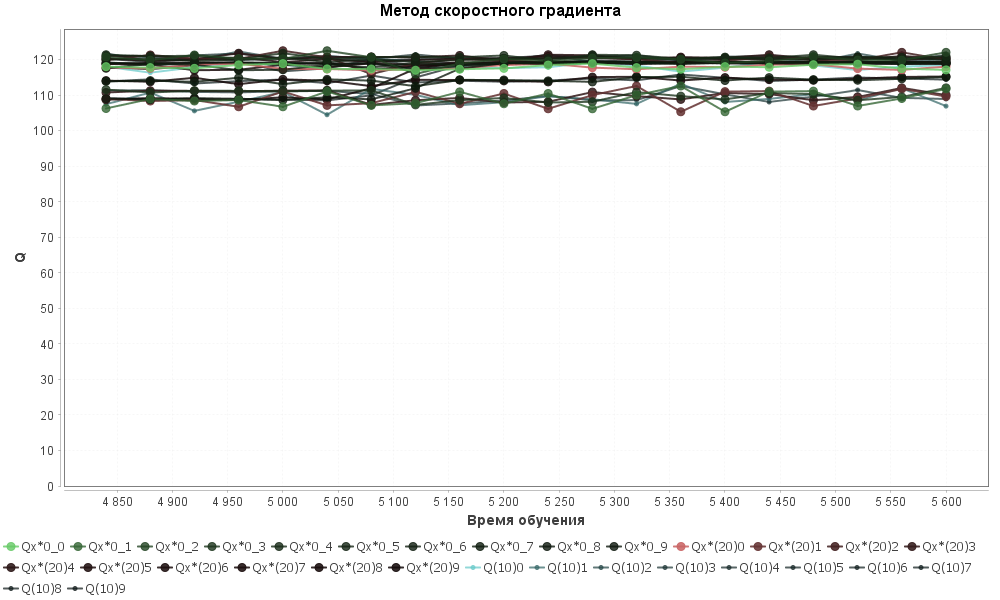

In [109]:
show_velg(hopfield_double, hopfield_errors, 4)
test_velgrad_fit(hopfield_double, hopfield_errors, patterns_numbers, show_steps = 20, fit_steps = 20, bound = 1000)
show_velg(hopfield_double, hopfield_errors, 4)

In [24]:
show_velg(hopfield_double, hopfield_errors, 20)

Fit Weights
	0,000000 0,453418 0,064879 0,013674 0,325656 0,292046 0,268529 -0,109453 -0,645703 -0,255854 -0,110741 -0,307206 0,272543 0,064965 0,200925 0,127617 -0,463387 0,160542 -0,192104 -0,385435 ... 
	0,453418 0,000000 0,262850 0,490612 -0,169762 0,312041 -0,514427 0,108944 0,367258 0,508518 -0,325703 -0,280094 0,329047 -0,145609 -0,363847 0,167905 0,210562 0,353867 -0,089263 0,134723 ... 
	0,064879 0,262850 0,000000 0,286574 -0,090250 0,006916 -0,148313 -0,438401 0,041669 -0,026561 -0,070070 -0,380024 0,153375 -0,031774 0,250419 0,082285 0,291397 0,233470 0,482500 -0,165952 ... 
	0,013674 0,490612 0,286574 0,000000 0,984219 0,173781 -0,378024 -0,125347 -0,088376 0,135669 0,105304 -0,244255 -0,756311 0,053510 0,169242 -0,390826 -0,095680 0,015133 -0,391868 0,188110 ... 
	0,325656 -0,169762 -0,090250 0,984219 0,000000 0,018422 0,211519 0,137395 -0,323179 0,099451 -0,127374 -0,029831 0,059239 -0,171827 0,075240 -0,219472 -0,144802 -0,279388 0,105177 -0,137414 ... 
	0,292046 0,31204

И график динамики после обучения на произвольном векторе

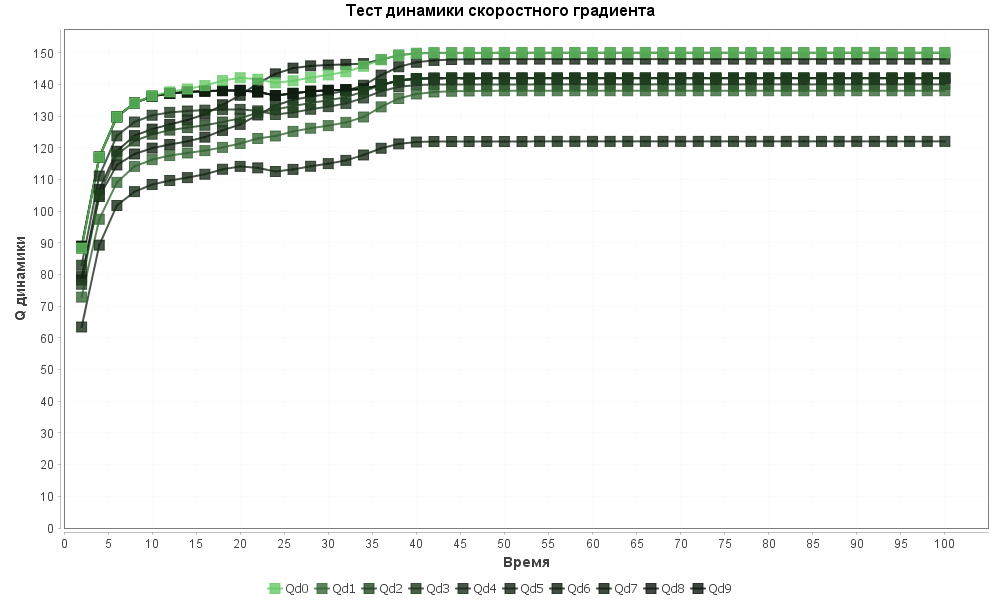

res139_0: HopfieldDynamic = ammonite.$sess.cmd10$Helper$HopfieldDynamic@314fe12b
res139_1: HopfieldModel = ammonite.$sess.cmd13$Helper$HopfieldModel@52358a15
res139_2: HopfieldDynamic = ammonite.$sess.cmd10$Helper$HopfieldDynamic@314fe12b

In [139]:
hopfield_double.dyn.set_time(0.0)
hopfield_double.move_fit_data(StepType.Dynamic, FitType.VelocityGradient)
hopfield_double.dyn.set_randomised_state(r1 = -3.0, r2 = 3.0)
display_patterns(Array(hopfield_double.dyn.get_x()), width_m, height_m, enc_m)
test_velgrad(hopfield_double, hopfield_errors, show_steps = 50, dynamic_steps =  1)
display_patterns(Array(hopfield_double.dyn.get_x()), width_m, height_m, enc_m)

Проверка стационарности

In [114]:
test_patterns_with_view(hopfield_double, patterns_numbers, StepType.Dynamic, 1000, width_m, height_m, enc_m, "After 1000 steps", 100)


After 1000 steps

Проверка на изображениях

In [116]:
display_patterns(patterns_numbers, width_m, height_m, enc_m)
display_patterns(patterns_numbers_error, width_m, height_m, enc_m)

test_patterns_with_view(hopfield_double, patterns_numbers_error, StepType.Dynamic, 1, width_m, height_m, enc_m, "After 1 step", 100)
test_patterns_with_view(hopfield_double, patterns_numbers_error, StepType.Dynamic, 5, width_m, height_m, enc_m, "After 5 steps", 100)

After 1 step

After 5 steps

Выведем все числа на случай проверки

In [117]:
show_velg(hopfield_double, hopfield_errors, 1000)

Fit Weights
	0,000000 -0,009119 -0,181883 -0,135505 -0,358287 0,131198 -0,051697 0,349614 -0,243034 0,121787 0,410409 -0,313111 0,462050 -0,245585 -0,411861 -0,155108 -0,245249 0,013456 -0,112121 0,024548 -0,411372 0,535012 -0,065668 -0,178816 0,053896 -0,060997 -0,054225 -0,254569 0,218335 -0,521103 0,402097 -0,305174 -0,143852 -0,135389 -0,094198 0,468343 0,131254 0,208656 0,240663 0,128416 0,599421 0,183996 ... 
	-0,009119 0,000000 0,420250 0,222967 0,417633 0,070626 -0,143285 -0,055789 0,062315 -0,064506 -0,184267 -0,103077 0,074696 -0,137989 0,288336 0,047365 -0,080623 -0,010832 -0,244748 -0,097688 0,139797 -0,435516 -0,064282 -0,389725 -0,306304 0,158888 0,173084 -0,242015 -0,046211 -0,150774 -0,192328 -0,095200 -0,045001 0,120888 0,214486 0,492404 -0,075135 0,176096 0,135467 0,153266 -0,072920 -0,125242 ... 
	-0,181883 0,420250 0,000000 -0,004410 0,209406 -0,261909 -0,207596 0,349173 0,349571 0,106502 0,249203 -0,327389 0,022225 -0,007790 -0,442091 0,199902 0,116445 0,043228 -0,